In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- CONFIGURAÇÃO ---
PASTA_DADOS = r"C:\Users\Juliana\Documents\USP\Engenharia de Software\TCC\Scripts\bases_originais_prf" 

In [2]:
# --- CONFIGURAÇÃO DA FONTE (ARIAL) ---
plt.rcParams['font.family'] = 'Arial'  # Define Arial para todo o gráfico
plt.rcParams['font.size'] = 11

carnival_ranges = {
    2015: pd.date_range('2015-02-13', '2015-02-18'),
    2016: pd.date_range('2016-02-05', '2016-02-10'),
    2017: pd.date_range('2017-02-24', '2017-03-01'),
    2018: pd.date_range('2018-02-09', '2018-02-14'),
    2019: pd.date_range('2019-03-01', '2019-03-06'),
    2020: pd.date_range('2020-02-21', '2020-02-26'),
    2021: pd.date_range('2021-02-12', '2021-02-17'),
    2022: pd.date_range('2022-04-20', '2022-04-24'),
    2023: pd.date_range('2023-02-17', '2023-02-22'),
    2024: pd.date_range('2024-02-09', '2024-02-14'),
    2025: pd.date_range('2025-02-28', '2025-03-05')
}

df_list = []
print("Gerando gráfico com fonte Arial...")

Gerando gráfico com fonte Arial...


In [3]:
# Leitura e Tratamento
arquivos = [f for f in os.listdir(PASTA_DADOS) if f.endswith('.csv')]
for arquivo in arquivos:
    try:
        caminho = os.path.join(PASTA_DADOS, arquivo)
        try:
            df = pd.read_csv(caminho, sep=';', encoding='latin1', low_memory=False)
        except:
            df = pd.read_csv(caminho, sep=';', encoding='utf-8', low_memory=False)
        
        df.columns = [c.lower() for c in df.columns]
        
        if 'uf' in df.columns:
            df_ba = df[df['uf'].str.upper() == 'BA'].copy()
            df_ba['data_completa'] = pd.to_datetime(df_ba['data_inversa'], errors='coerce')
            
            def is_carnaval(row):
                if pd.isnull(row['data_completa']): return False
                y = row['data_completa'].year
                if y in carnival_ranges:
                    return row['data_completa'] in carnival_ranges[y]
                return False

            df_ba['flag_carnaval'] = df_ba.apply(is_carnaval, axis=1)
            df_list.append(df_ba[df_ba['flag_carnaval'] == True])
    except:
        pass

if df_list:
    df_final = pd.concat(df_list, ignore_index=True)
    contagem = df_final['data_completa'].dt.year.value_counts().sort_index()

C:\Users\Juliana\AppData\Local\Temp\ipykernel_25412\2858627116.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ba['data_completa'] = pd.to_datetime(df_ba['data_inversa'], errors='coerce')


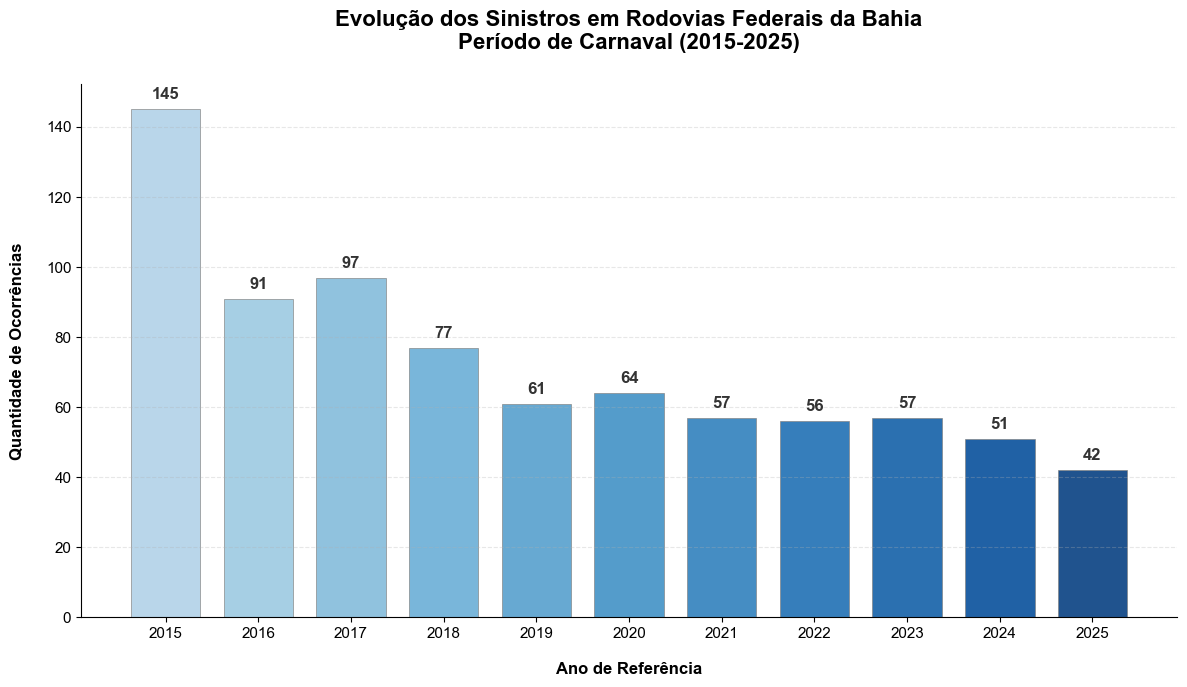

Gráfico salvo como 'validacao_carnaval_arial.png' com sucesso!


In [4]:
# --- INÍCIO DA ESTÉTICA ---
plt.figure(figsize=(12, 7))
    
# Degradê de Azuis (Ignorando os muito claros)
num_anos = len(contagem)
pulo_inicial = 4 
cores_degrade = sns.color_palette("Blues", num_anos + pulo_inicial)[pulo_inicial:]
    
# Barras
bars = plt.bar(contagem.index, contagem.values, color=cores_degrade, alpha=0.9, width=0.75, edgecolor='gray', linewidth=0.5)
    
# Rótulos de Dados
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333') # Cor cinza escuro para contraste

# Título e Eixos (Com Arial)
plt.title('Evolução dos Sinistros em Rodovias Federais da Bahia\nPeríodo de Carnaval (2015-2025)', 
           fontsize=16, fontweight='bold', pad=25, color='#000000') # Preto absoluto
plt.xlabel('Ano de Referência', fontsize=12, fontweight='bold', labelpad=15, color='#000000')
plt.ylabel('Quantidade de Ocorrências', fontsize=12, fontweight='bold', labelpad=15, color='#000000')
    
# Ajustes
plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
    
# Eixo X
plt.xticks(contagem.index, fontsize=11, rotation=0)
plt.yticks(fontsize=11)
    
plt.tight_layout()
plt.savefig('validacao_carnaval_arial.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'validacao_carnaval_arial.png' com sucesso!")
